# Parte 1 — Sistema de Controle Fuzzy (Mamdani)
## Manutencao preditiva industrial

**Disciplina:** Inteligencia Artificial e Computacional (0700M8) — CESUPA, 2026/01
**Modalidade:** Opcao B (produto) · motor **Mamdani**
**Equipe:** _(preencher)_

Este notebook executa, **celula a celula**, toda a modelagem fuzzy: variaveis e
universos, funcoes de pertinencia, base de regras, inferencia, cenarios de teste,
superficies de controle, sensibilidade e validacao quantitativa contra o dataset
**AI4I 2020 Predictive Maintenance** (UCI, 10.000 amostras).

O motor de inferencia, as MFs e as regras ficam em `src/` (codigo reutilizavel);
aqui focamos no *fluxo* e nas *evidencias*.

In [1]:
import os, sys
HERE = os.getcwd()
ROOT = HERE if os.path.isdir(os.path.join(HERE, "src")) else os.path.dirname(HERE)
sys.path.insert(0, ROOT)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)
print("repo root:", ROOT)

repo root: /Users/batman777/DEV/PYTHON/fuzzy-evolutionary


## 1. Problema e dados

Em manutencao preditiva, decidir *quando intervir* envolve **imprecisao** e
**gradacao**: um desgaste "alto" ou um torque "elevado" nao tem fronteira nitida.
A logica fuzzy modela esse julgamento linguistico melhor que um limiar rigido.

O dataset **AI4I 2020** registra variaveis de operacao de uma maquina e um rotulo
binario de falha. Ele e **desbalanceado** (~3,4% de falhas), entao a acuracia crua
e enganosa — usaremos **F1 da classe falha** na validacao.

In [2]:
from src.data_loader import load_dataset, stratified_split
ds = load_dataset()
print("amostras:", ds.X.shape, "| entradas:", ds.feature_names)
print(f"taxa de falhas: {ds.y.mean():.3%}  ({ds.y.sum()} de {len(ds.y)})")
pd.DataFrame(ds.X, columns=ds.feature_names).describe().round(1)

amostras: (10000, 3) | entradas: ['desgaste', 'torque', 'rotacao']
taxa de falhas: 3.390%  (339 de 10000)


,desgaste,torque,rotacao
count,10000.0,10000.0,10000.0
mean,108.0,40.0,1538.8
std,63.7,10.0,179.3
min,0.0,3.8,1168.0
25%,53.0,33.2,1423.0
50%,108.0,40.1,1503.0
75%,162.0,46.8,1612.0
max,253.0,76.6,2886.0


## 2. Variaveis linguisticas e universos de discurso

| Variavel | Papel | Universo | Termos | Justificativa |
|---|---|---|---|---|
| Desgaste da ferramenta | entrada | 0–260 min | Novo / Moderado / Desgastado | TWF e OSF crescem com o desgaste |
| Torque | entrada | 0–80 Nm | Baixo / Normal / Alto | OSF (desgaste×torque) e PWF (potencia) |
| Rotacao | entrada | 1100–2900 rpm | Baixa / Media / Alta | PWF (torque×rotacao) e HDF (rotacao baixa) |
| **Risco / urgencia** | **saida** | 0–100 | Baixa / Moderada / Alta / Critica | indice continuo de manutencao |

Os limites e parametros foram ancorados nos **quantis reais** do dataset
(desgaste q95≈206; torque q95≈56; rotacao q95≈1868) e nos limiares fisicos dos
modos de falha.

In [3]:
from src.fuzzy.system import build_default_system
system = build_default_system()
for v in list(system.inputs) + [system.output]:
    print(f"{v.name:9s} [{v.lo:g}, {v.hi:g}]  termos: {v.terms}")
print("n. de regras:", len(system.rules))

desgaste  [0, 260]  termos: ['Novo', 'Moderado', 'Desgastado']
torque    [0, 80]  termos: ['Baixo', 'Normal', 'Alto']
rotacao   [1100, 2900]  termos: ['Baixa', 'Media', 'Alta']
risco     [0, 100]  termos: ['Baixa', 'Moderada', 'Alta', 'Critica']
n. de regras: 20


## 3. Funcoes de pertinencia

Usamos MFs **triangulares** e **trapezoidais** (faceis de parametrizar e de
ajustar pelo otimizador da Parte 2). Os trapezios das pontas tem o ombro preso ao
limite do universo (saturacao). A tabela abaixo lista todos os parametros.

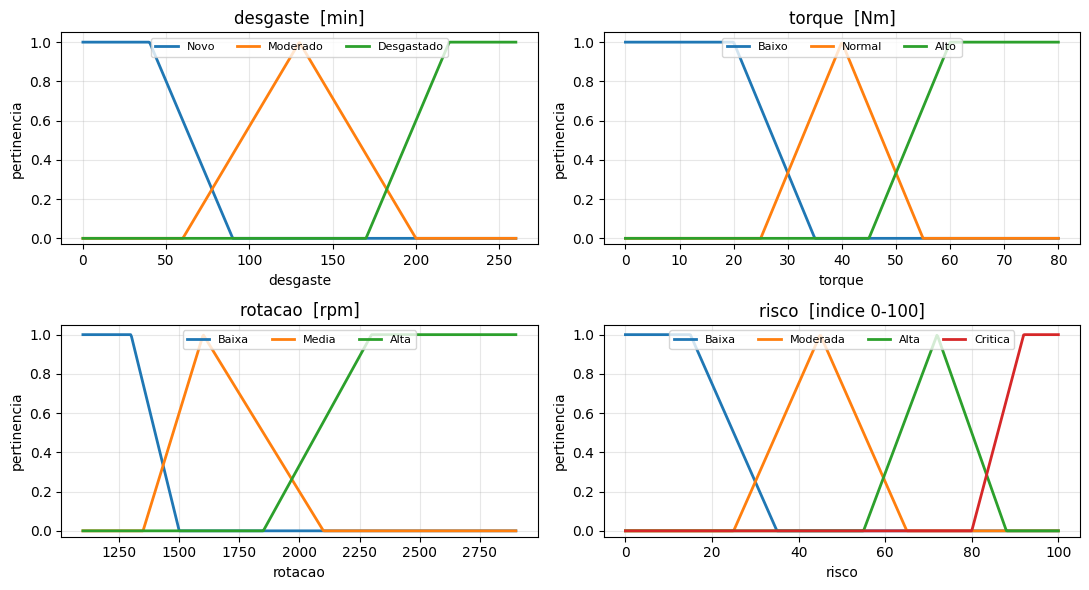

In [4]:
from src.plotting import plot_all_memberships
plot_all_memberships(system, save="01_mfs.png");

In [5]:
rows = []
for v in list(system.inputs) + [system.output]:
    for term, (kind, p) in v.mfs.items():
        rows.append({"variavel": v.name, "termo": term, "tipo": kind, "parametros": p})
pd.DataFrame(rows)

,variavel,termo,tipo,parametros
0,desgaste,Novo,trap,"[0, 0, 40, 90]"
1,desgaste,Moderado,tri,"[60, 130, 200]"
2,desgaste,Desgastado,trap,"[170, 220, 260, 260]"
3,torque,Baixo,trap,"[0, 0, 20, 35]"
4,torque,Normal,tri,"[25, 40, 55]"
5,torque,Alto,trap,"[45, 60, 80, 80]"
6,rotacao,Baixa,trap,"[1100, 1100, 1300, 1500]"
7,rotacao,Media,tri,"[1350, 1600, 2100]"
8,rotacao,Alta,trap,"[1850, 2300, 2900, 2900]"
9,risco,Baixa,trap,"[0, 0, 15, 35]"


## 4. Base de regras

**20 regras** (minimo exigido = 12), todas justificadas pelos modos de falha
documentados (TWF, OSF, PWF, HDF) e cobrindo casos tipicos, intermediarios,
criticos e conflitantes.

In [6]:
from src.fuzzy.rules import RULE_TABLE
reg = [{"#": i + 1,
        "SE": " e ".join(f"{k}={v}" for k, v in ant.items()),
        "ENTAO risco e": cons, "justificativa": just}
       for i, (ant, cons, just) in enumerate(RULE_TABLE)]
pd.DataFrame(reg).set_index("#")

,SE,ENTAO risco e,justificativa
#,,,
1,desgaste=Novo e torque=Normal e rotacao=Media,Baixa,regime nominal
2,desgaste=Novo e torque=Baixo e rotacao=Media,Baixa,"carga leve, ferramenta nova"
3,desgaste=Novo e torque=Normal e rotacao=Alta,Baixa,alta rotacao mas potencia ok
4,desgaste=Moderado e torque=Baixo e rotacao=Media,Baixa,"desgaste medio, carga leve"
5,desgaste=Moderado e torque=Normal e rotacao=Media,Moderada,envelhecimento normal
6,desgaste=Desgastado e torque=Baixo e rotacao=M...,Moderada,"TWF emergente, baixa carga"
7,desgaste=Desgastado e torque=Normal e rotacao=...,Alta,TWF + carga nominal
8,desgaste=Desgastado e torque=Baixo e rotacao=Alta,Alta,ferramenta gasta domina o risco
9,desgaste=Moderado e torque=Alto,Alta,OSF incipiente


## 5. Motor de inferencia Mamdani

Operadores: **AND = min**; **implicacao = min** (corte do consequente);
**agregacao = max**; **defuzzificacao = centroide**. O motor (`src/fuzzy/engine.py`)
e vetorizado: avalia as 10.000 amostras de uma vez (essencial para o AG/PSO).

In [7]:
r = system.predict_one(desgaste=235, torque=70, rotacao=1500)
print(f"desgaste=235 min, torque=70 Nm, rotacao=1500 rpm  ->  risco = {r:.1f}/100  (OSF severo)")

desgaste=235 min, torque=70 Nm, rotacao=1500 rpm  ->  risco = 92.7/100  (OSF severo)


## 6. Cenarios de teste

Seis cenarios cobrindo: baixo, medio, alto/critico, fronteirico, conflitante e
critico por baixa potencia.

In [8]:
cenarios = [
 ("Baixo (nominal)",         dict(desgaste=15,  torque=38, rotacao=1500), "ferramenta nova, carga nominal"),
 ("Medio (envelhecimento)",  dict(desgaste=120, torque=42, rotacao=1600), "desgaste moderado"),
 ("Alto/Critico (OSF)",      dict(desgaste=235, torque=70, rotacao=1500), "desgaste+torque -> sobre-esforco"),
 ("Fronteirico",             dict(desgaste=170, torque=45, rotacao=1500), "transicao entre termos"),
 ("Conflitante",             dict(desgaste=10,  torque=75, rotacao=2600), "alta potencia x ferramenta nova"),
 ("Critico (PWF baixa pot)", dict(desgaste=60,  torque=10, rotacao=1200), "potencia abaixo da faixa util"),
]
rows = []
for nome, inp, coment in cenarios:
    r = system.predict_one(**inp)
    nivel = "Baixa" if r < 35 else "Moderada" if r < 60 else "Alta" if r < 80 else "Critica"
    rows.append({**inp, "risco": round(r, 1), "nivel": nivel,
                 "cenario": nome, "interpretacao": coment})
pd.DataFrame(rows).set_index("cenario")

,desgaste,torque,rotacao,risco,nivel,interpretacao
cenario,,,,,,
Baixo (nominal),15,38,1500,14.6,Baixa,"ferramenta nova, carga nominal"
Medio (envelhecimento),120,42,1600,45.0,Moderada,desgaste moderado
Alto/Critico (OSF),235,70,1500,92.7,Critica,desgaste+torque -> sobre-esforco
Fronteirico,170,45,1500,45.0,Moderada,transicao entre termos
Conflitante,10,75,2600,56.9,Moderada,alta potencia x ferramenta nova
Critico (PWF baixa pot),60,10,1200,58.1,Moderada,potencia abaixo da faixa util


## 7. Superficies de controle

Mostram como o risco varia em funcao de pares de entradas (a terceira fixa).
Revelam as regioes de OSF (desgaste×torque) e PWF (torque×rotacao).

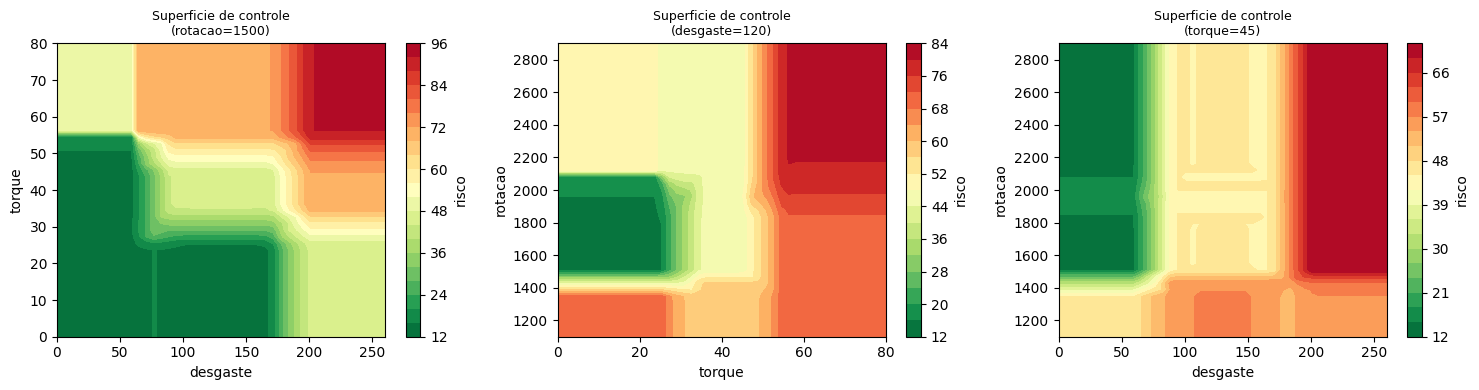

In [9]:
from src.plotting import plot_control_surface
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_control_surface(system, "desgaste", "torque",  {"rotacao": 1500}, ax=axes[0])
plot_control_surface(system, "torque",   "rotacao", {"desgaste": 120}, ax=axes[1])
plot_control_surface(system, "desgaste", "rotacao", {"torque": 45},    ax=axes[2])
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "results/figures/01_surfaces.png"), dpi=120, bbox_inches="tight");

## 8. Curvas de sensibilidade

Variamos uma entrada por vez (as demais fixas no ponto medio de operacao) para
avaliar a resposta do sistema e localizar os trechos mais sensiveis.

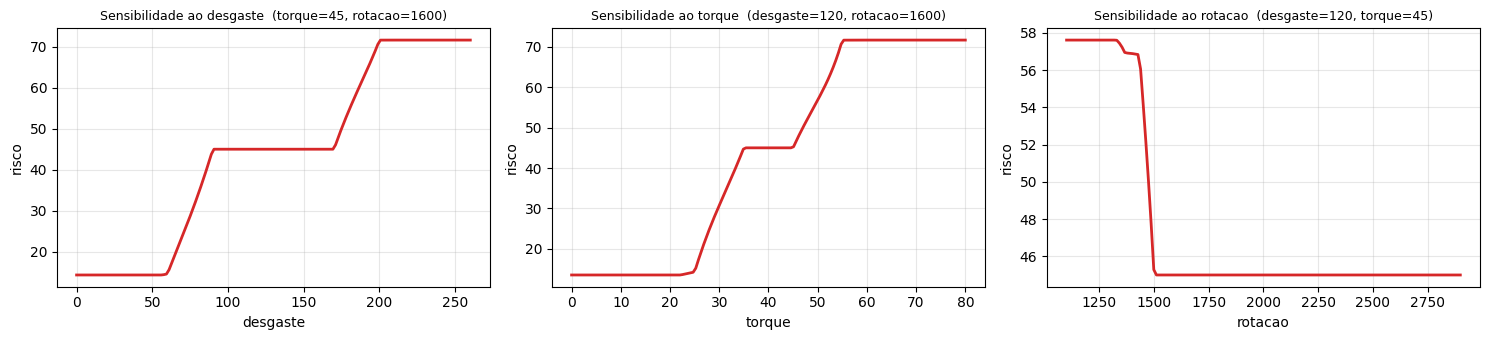

In [10]:
from src.plotting import plot_sensitivity
base = dict(desgaste=120, torque=45, rotacao=1600)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, var in zip(axes, ["desgaste", "torque", "rotacao"]):
    plot_sensitivity(system, var, base, ax=ax)
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "results/figures/01_sensitivity.png"), dpi=120, bbox_inches="tight");

## 9. Validacao quantitativa (baseline manual vs rotulos reais)

A saida continua do fuzzy vira decisao binaria por um **limiar** escolhido no
treino (maximizando F1). Avaliamos no teste (split estratificado 70/30).

limiar otimo (treino) = 74.4
TESTE: F1=0.346  precisao=0.500  recall=0.265  acuracia=0.966  J(Youden)=0.255


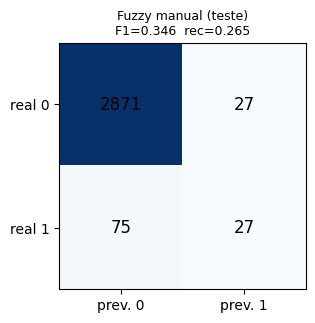

In [11]:
from src.metrics import best_threshold, score_binary
from src.plotting import plot_confusion
tr, te = stratified_split(ds, seed=42)
risk_tr, risk_te = system.predict(tr.X), system.predict(te.X)
thr, f1_tr = best_threshold(risk_tr, tr.y, "f1")
sc = score_binary(te.y, risk_te >= thr)
print(f"limiar otimo (treino) = {thr:.1f}")
print(f"TESTE: F1={sc.f1:.3f}  precisao={sc.precision:.3f}  recall={sc.recall:.3f}  "
      f"acuracia={sc.accuracy:.3f}  J(Youden)={sc.youden_j:.3f}")
os.makedirs(os.path.join(ROOT, "results/tables"), exist_ok=True)
pd.DataFrame([sc.as_dict()]).to_csv(os.path.join(ROOT, "results/tables/baseline_metrics.csv"), index=False)
plot_confusion(sc, title="Fuzzy manual (teste)", save="01_confusion_baseline.png");

## Conclusao da Parte 1

O sistema fuzzy manual ja e **interpretavel** e **funcional**: cada decisao e
rastreavel ate regras com justificativa fisica, e o F1 no teste fica em torno de
**0,35** num problema fortemente desbalanceado.

A **Parte 2** (`02_otimizacao_evolutiva.ipynb`) ajusta automaticamente os
parametros das funcoes de pertinencia via **Algoritmo Genetico** e **PSO**,
elevando o F1 sem perder a interpretabilidade — comparando *antes x depois*.